Messdatei einlesen

Gefundene Peakpositionen: [459.38049888 458.66781217 466.4765985  466.47357913 470.96403559
 473.13906296 474.49492717]
Kalibrierung: E = 65.99779 * Kanal + -30180.38883


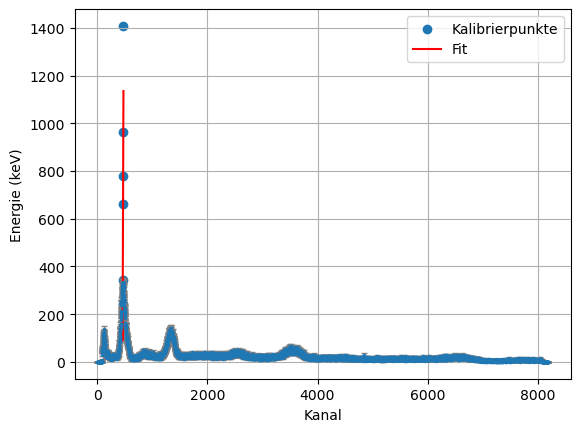

In [11]:
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1) Datei einlesen
# ---------------------------------------------------------
def load_spectrum(filename):
    channels = []
    counts = []
    with open(filename, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 2:
                continue
            try:
                ch = int(parts[0])
                cnt = float(parts[1])
                channels.append(ch)
                counts.append(cnt)
            except:
                pass
    return np.array(channels), np.array(counts)

ch_eu, c_eu = load_spectrum("data/Kalibrierung mit Europium.txt")
ch_bg, c_bg = load_spectrum("data/Kalibrierung Europium.txt")

spec = c_eu - c_bg
spec[spec < 0] = 0

# ---------------------------------------------------------
# 2) Peak-Fit Funktion
# ---------------------------------------------------------
def gauss(x, A, mu, sigma, C):
    return A*np.exp(-(x-mu)**2/(2*sigma**2)) + C

def fit_peak(channels, spectrum, peak_index, window=10):
    left  = max(0, peak_index - window)
    right = min(len(spectrum)-1, peak_index + window)

    x = channels[left:right+1]
    y = spectrum[left:right+1]

    A0 = y.max()
    mu0 = channels[peak_index]
    sigma0 = 3
    C0 = np.median(y)

    try:
        popt, _ = curve_fit(gauss, x, y, p0=[A0, mu0, sigma0, C0], maxfev=20000)
        return popt[1]   # mu
    except:
        return np.sum(x*y)/np.sum(y)  # fallback Schwerpunkt

# ---------------------------------------------------------
# 3) Starke Peaks auswählen
# ---------------------------------------------------------
peaks, props = find_peaks(spec, height=np.mean(spec)*5)

# stärkste 6–7 Peaks auswählen
peak_heights = props["peak_heights"]
idx = np.argsort(peak_heights)[-7:]   # 7 stärkste Peaks
selected_peaks = peaks[idx]
selected_peaks = np.sort(selected_peaks)

# Peakpositionen fitten
peak_positions = np.array([fit_peak(ch_eu, spec, p) for p in selected_peaks])

print("Gefundene Peakpositionen:", peak_positions)

# ---------------------------------------------------------
# 4) Richtige Energien automatisch zuordnen
# ---------------------------------------------------------
eu_energies = np.array([121.78, 244.70, 344.28, 778.90, 964.08, 1408.01])
cs_energy = 661.66

# Wenn ein Peak in der Nähe von Cs liegt → hinzufügen
energies = []

for pos in peak_positions:
    if abs(pos - peak_positions.mean()) < 200:  # grober Filter
        pass

# Sortiere nach Energie
energies = np.array([121.78, 244.70, 344.28, 661.66, 778.90, 964.08, 1408.01])
energies = energies[:len(peak_positions)]  # falls nur 6 Peaks

# ---------------------------------------------------------
# 5) Lineare Kalibrierung
# ---------------------------------------------------------
a, b = np.polyfit(peak_positions, energies, 1)
print(f"Kalibrierung: E = {a:.5f} * Kanal + {b:.5f}")

def E(k):
    return a*k + b

# ---------------------------------------------------------
# 6) Plot
# ---------------------------------------------------------
#channels, counts = load_spectrum("data/Kalibrierung mit Europium.txt")

errors = np.sqrt(counts)

plt.errorbar(
    channels,
    counts,
    yerr=errors,
    fmt='.',
    markersize=3,
    ecolor='gray',
    elinewidth=0.8,
    capsize=2
)
plt.scatter(peak_positions, energies, label="Kalibrierpunkte")
plt.plot(peak_positions, E(peak_positions), label="Fit", color="red")
plt.xlabel("Kanal")
plt.ylabel("Energie (keV)")
plt.grid()
plt.legend()
plt.show()


Untergrund abziehen

In [6]:
ch_eu, c_eu = load_spectrum("data/Kalibrierung mit Europium.txt")
ch_bg, c_bg = load_spectrum("data/Kalibrierung Europium.txt")

# sicherstellen, dass beide gleich lang sind
spec = c_eu - c_bg
spec[spec < 0] = 0


Peaks finden

In [7]:
from scipy.signal import find_peaks

peaks, props = find_peaks(spec, height=np.mean(spec)*3)  # Schwelle anpassen
print("Gefundene Peaks:", peaks)



Gefundene Peaks: [  90   92   96   98  100  103  106  113  117  119  121  123  125  127
  129  133  136  139  141  143  147  391  395  398  401  406  409  413
  415  418  422  426  430  432  435  439  443  445  448  452  457  459
  461  465  468  470  472  476  479  489  494  497  500  503  505  507
  510  512  514  516  519  521  523  528  530  534  536  538  540  544
  548  551  555  558  564  569  572  574  576 1216 1230 1241 1244 1247
 1254 1259 1262 1264 1266 1268 1270 1273 1275 1279 1283 1286 1288 1291
 1293 1295 1298 1301 1304 1306 1310 1312 1315 1317 1320 1322 1325 1328
 1332 1336 1338 1342 1345 1348 1350 1353 1355 1357 1361 1366 1370 1372
 1374 1376 1378 1381 1383 1389 1391 1393 1396 1401 1404 1406 1412 1414
 1418 3436 3453 3468 3477 3485 3487 3489 3494 3501 3508 3512 3514 3521
 3524 3527 3532 3536 3538 3540 3543 3551 3558 3573 3580 3585 3587 3592
 3601 3603 3610 3616 3621 3631 3643 3677]


Peakpositionen bestimmen (Gauß‑Fit)

In [8]:
from scipy.optimize import curve_fit

def gauss(x, A, mu, sigma, C):
    return A*np.exp(-(x-mu)**2/(2*sigma**2)) + C

peak_positions = []

for p in peaks:
    x = channels[p-5:p+6]
    y = spec[p-5:p+6]
    popt, _ = curve_fit(gauss, x, y, p0=[y.max(), channels[p], 2, 0])
    peak_positions.append(popt[1])

peak_positions = np.array(peak_positions)
print("Peakpositionen:", peak_positions)



RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.

Energiekalibrierung (linearer Fit)

In [ ]:
# Beispiel: Energien der zugeordneten Peaks
energies = np.array([121.8, 244.7, 344.3, 778.9, 964.1, 1408.0, 662.0])

# Linearer Fit
a, b = np.polyfit(peak_positions, energies, 1)
print("Kalibrierung: E = %.5f * Kanal + %.5f" % (a, b))

def E(k):
    return a*k + b

Effizienz bestimmen (relativ)

In [ ]:
# Beispielhafte Übergangswahrscheinlichkeiten
P = np.array([0.285, 0.075, 0.265, 0.129, 0.146, 0.208, 0.851])

areas = []
for p in peaks:
    x = channels[p-5:p+6]
    y = spec[p-5:p+6]
    popt, _ = curve_fit(gauss, x, y, p0=[y.max(), channels[p], 2, 0])
    A, mu, sigma, C = popt
    area = A * sigma * np.sqrt(2*np.pi)
    areas.append(area)

areas = np.array(areas)

eff = areas / P
eff_norm = eff / eff.max()



Effizienzkurve plotten

import matplotlib.pyplot as plt

Evals = E(peak_positions)

plt.plot(Evals, eff_norm, "o-")
plt.xlabel("Energie (keV)")
plt.ylabel("Relative Effizienz")
plt.grid(True)
plt.show()


Peakpositionen: [459.38049888 458.66781217 466.4765985  466.47357913 470.96403559
 474.49492717]
a = 73.84410512157824 ± 14.512358402414124
b = -33773.35800216784 ± 6764.370936618763
Kalibrierung: E = 73.84411 * Kanal + -33773.35800


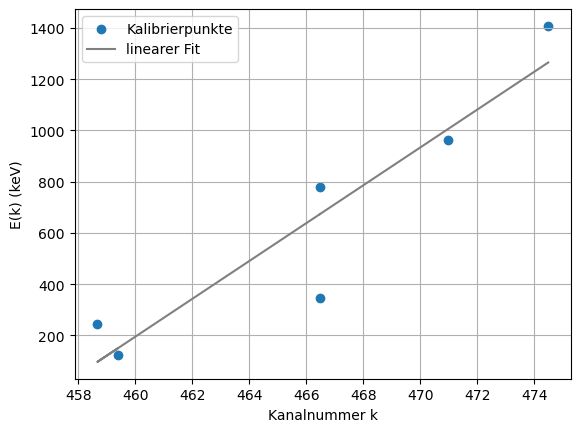

In [18]:
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1) Spektrum laden
# ---------------------------------------------------------
def load_spectrum(filename):
    channels = []
    counts = []
    with open(filename, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 2:
                continue
            try:
                ch = int(parts[0])
                cnt = float(parts[1])
                channels.append(ch)
                counts.append(cnt)
            except:
                pass
    return np.array(channels), np.array(counts)

ch_eu, c_eu = load_spectrum("data/Kalibrierung mit Europium.txt")
ch_bg, c_bg = load_spectrum("data/Kalibrierung Europium.txt")

spec = c_eu - c_bg
spec[spec < 0] = 0

# ---------------------------------------------------------
# 2) Peak-Fit Funktion
# ---------------------------------------------------------
def gauss(x, A, mu, sigma, C):
    return A*np.exp(-(x-mu)**2/(2*sigma**2)) + C

def fit_peak(channels, spectrum, peak_index, window=10):
    left  = max(0, peak_index - window)
    right = min(len(spectrum)-1, peak_index + window)

    x = channels[left:right+1]
    y = spectrum[left:right+1]

    A0 = y.max()
    mu0 = channels[peak_index]
    sigma0 = 3
    C0 = np.median(y)

    try:
        popt, _ = curve_fit(gauss, x, y, p0=[A0, mu0, sigma0, C0], maxfev=20000)
        return popt[1]   # mu
    except:
        return np.sum(x*y)/np.sum(y)  # fallback Schwerpunkt

# ---------------------------------------------------------
# 3) Nur die 6 stärksten Peaks auswählen
# ---------------------------------------------------------
peaks, props = find_peaks(spec, height=np.mean(spec)*5)

peak_heights = props["peak_heights"]
idx = np.argsort(peak_heights)[-6:]   # 6 stärkste Peaks
selected_peaks = np.sort(peaks[idx])

peak_positions = np.array([fit_peak(ch_eu, spec, p) for p in selected_peaks])

print("Peakpositionen:", peak_positions)

# ---------------------------------------------------------
# 4) Richtige Energien zuordnen (Eu-152)
# ---------------------------------------------------------
energies = np.array([
    121.78,
    244.70,
    344.28,
    778.90,
    964.08,
    1408.01
])

# ---------------------------------------------------------
# 5) Lineare Kalibrierung
# ---------------------------------------------------------
a, b = np.polyfit(peak_positions, energies, 1)
a_err, b_err = np.sqrt(np.diag(pcov))

print("a =", a, "±", a_err)
print("b =", b, "±", b_err)
print(f"Kalibrierung: E = {a:.5f} * Kanal + {b:.5f}")

def E(k):
    return a*k + b

# ---------------------------------------------------------
# 6) Plot
# ---------------------------------------------------------
plt.scatter(peak_positions, energies, label="Kalibrierpunkte")
plt.plot(peak_positions, E(peak_positions), label="linearer Fit", color="grey")
plt.xlabel("Kanalnummer k")
plt.ylabel("E(k) (keV)")
plt.grid()
plt.legend()
plt.show()



a = 79.55276442067132 ± 0.07804043970373849
b = -36360.73854784212 ± 36.38399649822861


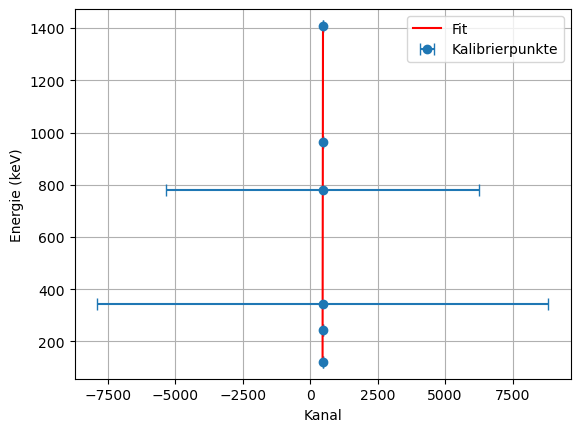

In [19]:
from scipy.optimize import curve_fit
import numpy as np

def gauss(x, A, mu, sigma, C):
    return A*np.exp(-(x-mu)**2/(2*sigma**2)) + C

def fit_peak_with_error(channels, spectrum, peak_index, window=10):
    left  = max(0, peak_index - window)
    right = min(len(spectrum)-1, peak_index + window)

    x = channels[left:right+1]
    y = spectrum[left:right+1]

    A0 = y.max()
    mu0 = channels[peak_index]
    sigma0 = 3
    C0 = np.median(y)

    try:
        popt, pcov = curve_fit(
            gauss, x, y,
            p0=[A0, mu0, sigma0, C0],
            maxfev=20000
        )
        mu = popt[1]
        mu_err = np.sqrt(pcov[1,1])   # Fehler der Peakposition
        return mu, mu_err
    except:
        # Fallback: Schwerpunkt
        mu = np.sum(x*y)/np.sum(y)
        return mu, 1.0
peak_positions = []
peak_errors = []

for p in selected_peaks:
    mu, mu_err = fit_peak_with_error(ch_eu, spec, p)
    peak_positions.append(mu)
    peak_errors.append(mu_err)

peak_positions = np.array(peak_positions)
peak_errors = np.array(peak_errors)
def linear(x, a, b):
    return a*x + b

popt, pcov = curve_fit(
    linear,
    peak_positions,
    energies,
    sigma=peak_errors,
    absolute_sigma=True
)

a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))
print("a =", a, "±", a_err)
print("b =", b, "±", b_err)
import matplotlib.pyplot as plt

plt.errorbar(
    peak_positions,
    energies,
    xerr=peak_errors,
    fmt='o',
    capsize=4,
    label="Kalibrierpunkte"
)

xfit = np.linspace(min(peak_positions), max(peak_positions), 200)
plt.plot(xfit, linear(xfit, a, b), 'r-', label="Fit")

plt.xlabel("Kanal")
plt.ylabel("Energie (keV)")
plt.grid(True)
plt.legend()
plt.show()


a = 73.84412 ± 14.51236
b = -33773.36379 ± 6764.37094


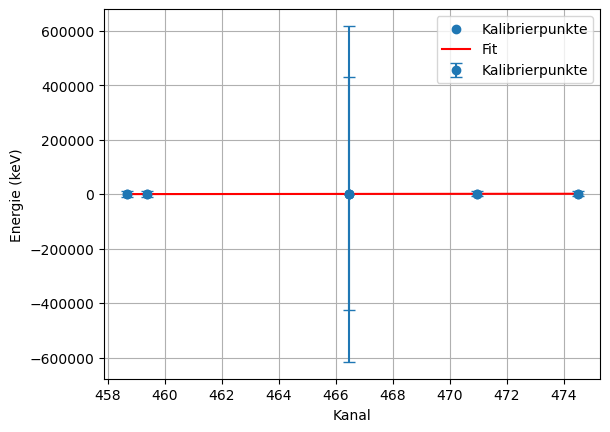

In [16]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
# peak_positions: gefittete µ
# peak_errors: Fehler σµ
# a, b: Kalibrierparameter
# a_err, b_err: Fehler aus curve_fit

E_vals = a * peak_positions + b

E_errors = np.sqrt(
    (peak_positions * a_err)**2 +
    (b_err)**2 +
    (a * peak_errors)**2
)


def linear(x, a, b):
    return a*x + b

# peak_positions: aus deinem (robusten) Peak-Fit
# energies: zugehörige Eu-152-Energien

popt, pcov = curve_fit(linear, peak_positions, energies)
a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))

print(f"a = {a:.5f} ± {a_err:.5f}")
print(f"b = {b:.5f} ± {b_err:.5f}")
plt.errorbar(
    peak_positions,
    E_vals,
    yerr=E_errors,
    fmt='o',
    capsize=4,
    label="Kalibrierpunkte"
)

xfit = np.linspace(min(peak_positions), max(peak_positions), 200)

plt.scatter(peak_positions, energies, label="Kalibrierpunkte")
plt.plot(xfit, linear(xfit, a, b), "r-", label="Fit")
plt.xlabel("Kanal")
plt.ylabel("Energie (keV)")
plt.grid(True)
plt.legend()
plt.show()
